In [ ]:
# using GNNs to build network graph from nmap output

# Read the XML `nmap` Output
- Parse `.xml` into nodes, edges, attributes.

Note:
What I have now is not universal, I will need our true `nmap` scans to make this one-size fits all.

In [4]:
import xml.etree.ElementTree as ET  # ElementTree library is used to parse XML data
import os

xml1 = "../data/nmap_output.xml"
xml2 = "../data/nmap_output_adv.xml"
xml3 = "../data/nmap_stress_test.xml"
xml4 = "../data/2025-10-21T19_16_43_990690Z_nmap.xml"



In [5]:
def xml_parse(xml_data):
    """
    Parses Nmap XML output into a structured dictionary.
    Handles missing fields and multiple addresses/hostnames.
    """
    network_config = {}

    if not xml_data:
        return {}

    # Parse XML (from file or string)
    try:
        if os.path.exists(xml_data):
            tree = ET.parse(xml_data)
            root = tree.getroot()
        else:
            s = xml_data.strip()
            if not s.startswith("<"):
                return {"error": "~INPUT DOES NOT APPEAR TO BE XML"}
            root = ET.fromstring(s)
    except ET.ParseError as pe:
        return {"error": f"~ISSUE PARSING ELEMENTTREE: {pe}"}
    except Exception as e:
        return {"error": f"~UNEXPECTED ERROR PARSING XML: {e}"}

    # Iterate over each host
    for host in root.findall("host"):
        addresses = []
        hostnames = []

        # --- Extract addresses ---
        for addr_elem in host.findall("address"):
            addr = addr_elem.attrib.get("addr")
            addrtype = addr_elem.attrib.get("addrtype")
            if addr:
                addresses.append({"addr": addr, "type": addrtype or "unknown"})

        # --- Extract hostnames ---
        for hostname_elem in host.findall("hostnames/hostname"):
            name = hostname_elem.attrib.get("name")
            if name:
                hostnames.append(name)

        # --- Extract ports ---
        ports_list = []
        ports_elem = host.find("ports")
        if ports_elem is not None:
            for port in ports_elem.findall("port"):
                port_data = {
                    "port": port.attrib.get("portid"),
                    "protocol": port.attrib.get("protocol"),
                }

                # Extract state
                state_elem = port.find("state")
                if state_elem is not None:
                    port_data.update({
                        "state": state_elem.attrib.get("state", "unknown"),
                        "reason": state_elem.attrib.get("reason", "unknown"),
                        "reason_ttl": state_elem.attrib.get("reason_ttl", "unknown"),
                    })
                else:
                    port_data.update({"state": "unknown", "reason": None, "reason_ttl": None})

                # Extract service
                service_elem = port.find("service")
                if service_elem is not None:
                    port_data.update({
                        "service": service_elem.attrib.get("name", "unknown"),
                        "product": service_elem.attrib.get("product"),
                        "version": service_elem.attrib.get("version"),
                        "extrainfo": service_elem.attrib.get("extrainfo")
                    })
                else:
                    port_data.update({"service": "unknown", "product": None, "version": None, "extrainfo": None})

                ports_list.append(port_data)

        # --- Assign to all addresses ---
        for addr in addresses:
            network_config[addr["addr"]] = {
                "addr_type": addr["type"],
                "hostnames": hostnames or ["unknown"],
                "ports": ports_list
            }

    return network_config



network = xml_parse(xml4)
print(network)

{'10.10.162.98': {'addr_type': 'ipv4', 'hostnames': ['unknown'], 'ports': []}, '66:9D:6F:44:AE:93': {'addr_type': 'mac', 'hostnames': ['unknown'], 'ports': []}, '10.10.162.157': {'addr_type': 'ipv4', 'hostnames': ['unknown'], 'ports': [{'port': '62078', 'protocol': 'tcp', 'state': 'open', 'reason': 'syn-ack', 'reason_ttl': '64', 'service': 'tcpwrapped', 'product': None, 'version': None, 'extrainfo': None}]}, 'C0:2C:5C:68:E9:E4': {'addr_type': 'mac', 'hostnames': ['unknown'], 'ports': [{'port': '62078', 'protocol': 'tcp', 'state': 'open', 'reason': 'syn-ack', 'reason_ttl': '64', 'service': 'tcpwrapped', 'product': None, 'version': None, 'extrainfo': None}]}, '10.10.162.163': {'addr_type': 'ipv4', 'hostnames': ['unknown'], 'ports': [{'port': '22', 'protocol': 'tcp', 'state': 'open', 'reason': 'syn-ack', 'reason_ttl': '64', 'service': 'ssh', 'product': 'Dropbear sshd', 'version': '2020.80', 'extrainfo': 'protocol 2.0'}, {'port': '53', 'protocol': 'tcp', 'state': 'filtered', 'reason': 'no-

In [ ]:
tree = ET.parse(xml1)
root = tree.getroot()  # tag that envelopes everything
root.attrib  # length of 6 (scaninfo, host1, host2, host3, host4, runstats)

In [7]:
# # loop over root children and their sub attributes
# # find each HOST element
# network = {}
# for child in root: 
#     network_config = {}

#     # skip over none host elements
#     if child.tag != "host":
#         continue

#     # pull all IP hosts found (up/down)
#     addr = child.findall("address")  # might not be universal (can have ipv4/mac)
#     ip_addr = None
#     mac_addr = None
#     for a in addr:
#         # store ipv4 as the main key
#         if a.attrib["addrtype"] == "ipv4":
#             ip_addr = a.attrib["addr"]

#         # if a mac address exists store it
#         if a.attrib["addrtype"] == "mac":
#             # store other address types
#             mac_addr = a.attrib["addr"]
#             vendor = a.attrib.get("vendor", None)
#             network_config["address"] = {"mac_addr" : mac_addr, "vendor": vendor}

#     # use mac as main key if ipv4 not available
#     if not ip_addr and mac_addr is not None:
#         print("~NO IPV4 VALUE USING MAC INSTEAD")
#         ip_addr = mac_addr
        
#     # find host's state
#     status = child.find("status").attrib["state"]
#     if status != "up":  # host is down
#         network_config["os"] = None
#         network_config["state"] = None
#         network_config["hostname"] = None
#         network_config["ports"] = None
#     else:   # host is up
#         # find IP hostname (might contain multiple or none)
#         hostname_root = child.find("hostnames")
#         if hostname_root is not None:
#             hostname_list = []
#             for host in hostname_root:
#                 hostname_list.append(host.attrib) 
#         else:
#             hostname_list = None

#         # find IP OS (either single or multiple)
#         os_root = child.find("os")
#         if os_root is not None:
#             osmatch = os_root.findall("osmatch")
#             os_lst = []
#             for o in osmatch:
#                 os_pred = o.attrib
#                 os_lst.append(os_pred)
#             network_config["os"] = os_lst
#         else: 
#             network_config["os"] = None

#         network_config["state"] = status 
#         network_config["hostname"] = hostname_list  # store list of hostnames if contains multiple

#         # find IP open ports
#         port_root = child.find("ports")
#         if port_root is not None:
#             port_lst = []
#             for port in port_root.findall("port"):
#                 port_data = dict(port.attrib)
#                 for child in port:
#                     if child.tag in ("state", "service"):
#                         port_data.update(child.attrib)
#                 port_lst.append(port_data)

#         network_config["ports"] = port_lst

#     # add the host into the dictionary
#     network[ip_addr] = network_config
    
# print(network)


## Turn ElementTree Dictionary into `networkx` graph.

In [8]:
print(network)

{'10.10.162.98': {'addr_type': 'ipv4', 'hostnames': ['unknown'], 'ports': []}, '66:9D:6F:44:AE:93': {'addr_type': 'mac', 'hostnames': ['unknown'], 'ports': []}, '10.10.162.157': {'addr_type': 'ipv4', 'hostnames': ['unknown'], 'ports': [{'port': '62078', 'protocol': 'tcp', 'state': 'open', 'reason': 'syn-ack', 'reason_ttl': '64', 'service': 'tcpwrapped', 'product': None, 'version': None, 'extrainfo': None}]}, 'C0:2C:5C:68:E9:E4': {'addr_type': 'mac', 'hostnames': ['unknown'], 'ports': [{'port': '62078', 'protocol': 'tcp', 'state': 'open', 'reason': 'syn-ack', 'reason_ttl': '64', 'service': 'tcpwrapped', 'product': None, 'version': None, 'extrainfo': None}]}, '10.10.162.163': {'addr_type': 'ipv4', 'hostnames': ['unknown'], 'ports': [{'port': '22', 'protocol': 'tcp', 'state': 'open', 'reason': 'syn-ack', 'reason_ttl': '64', 'service': 'ssh', 'product': 'Dropbear sshd', 'version': '2020.80', 'extrainfo': 'protocol 2.0'}, {'port': '53', 'protocol': 'tcp', 'state': 'filtered', 'reason': 'no-

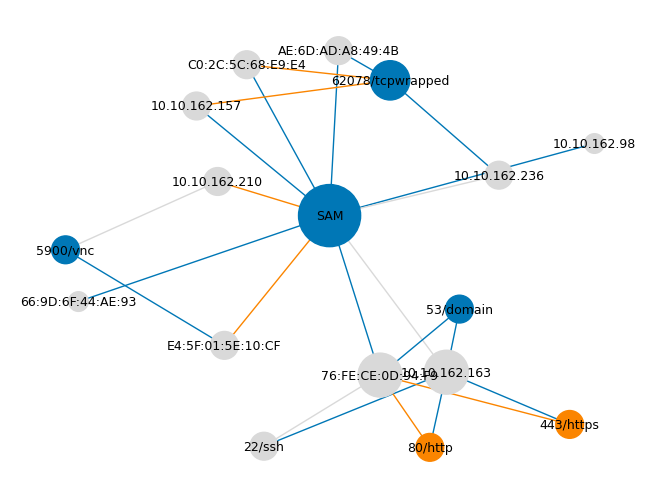

<Figure size 640x480 with 0 Axes>

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

# ----------------------------
# CONFIGURATION
# ----------------------------
SCANNER = "SAM"
PORT_COLORS = {
    80: "#fb8500",   # HTTP
    443: "#fb8500",  # HTTPS
    22: "#d9d9d9",   # SSH
}
DEFAULT_NODE_COLOR = "#0077b6"
IP_UP_COLOR = "#4c956c"
IP_DOWN_COLOR = "#d9d9d9"

# ----------------------------
# FUNCTION: Build Graph
# ----------------------------
def build_network_graph(network_dict):
    G = nx.Graph()
    G.add_node(SCANNER)

    for ip, info in network_dict.items():
        state = info.get("state", "unknown")
        ip_color = IP_UP_COLOR if state == "up" else IP_DOWN_COLOR

        # Add IP node
        G.add_node(ip, color=ip_color)

        # Connect scanner to IP
        G.add_edge(SCANNER, ip)

        # Add ports
        for port_info in info.get("ports", []):
            port_number = int(port_info.get("port", 0))
            service_name = port_info.get("service", "unknown")
            port_label = f"{port_number}/{service_name}"

            # Add port node and edge
            G.add_node(port_label, color=PORT_COLORS.get(port_number, DEFAULT_NODE_COLOR))
            G.add_edge(ip, port_label, color=PORT_COLORS.get(port_number, DEFAULT_NODE_COLOR))

    return G

# ----------------------------
# FUNCTION: Draw Graph
# ----------------------------
def draw_network_graph(G):
    # Node colors
    node_colors = [G.nodes[n].get("color", DEFAULT_NODE_COLOR) for n in G.nodes()]
    # Edge colors
    edge_colors = list(nx.get_edge_attributes(G, "color").values())
    # Node size proportional to degree
    node_sizes = [v * 200 for _, v in G.degree()]

    # Draw the graph
    pos = nx.spring_layout(G, k=1, seed=42)  # nicer spacing
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=node_sizes,
        font_size=9
    )
    plt.show()
    plt.savefig("../output/new_xml_output.png")

# ----------------------------
# MAIN EXECUTION
# ----------------------------
G = build_network_graph(network)
draw_network_graph(G)


## Turn `networkx` graph into GNN graph.

In [ ]:
import torch
from torch_geometric.utils.convert import to_networkx, from_networkx

pyg_graph = from_networkx(G)
pyg_graph

## Output GNN graph object.

## Next Steps
- `<extraports>` summarize/show closed ports
- define multiple  `<host>` with no IPv4 or MAC

These next steps can be tuned when we get actual nmap scans.